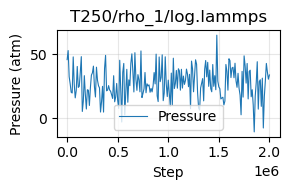

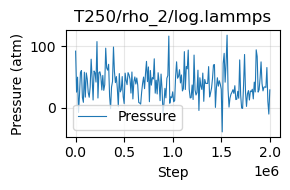

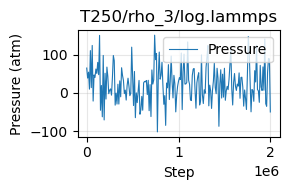

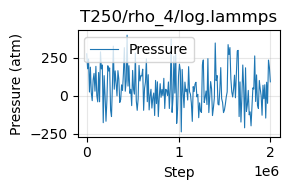

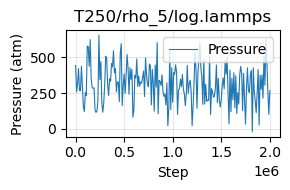

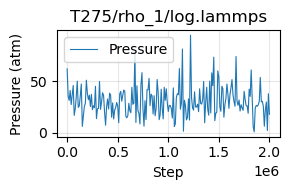

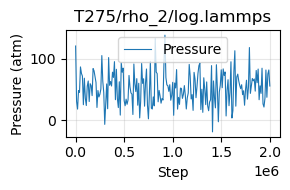

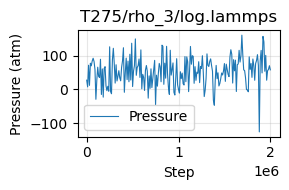

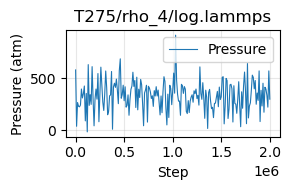

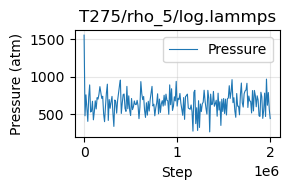

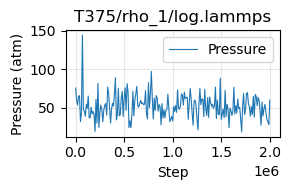

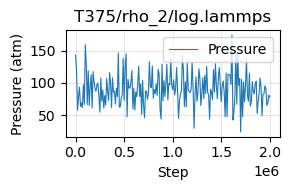

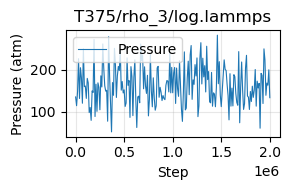

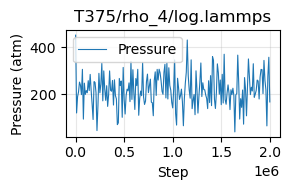

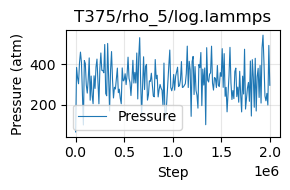

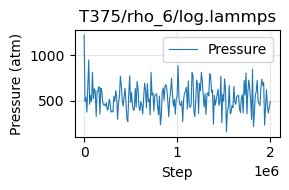

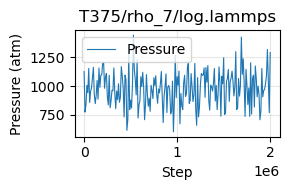

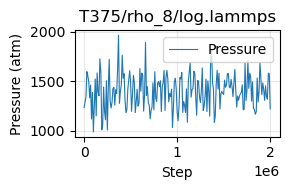

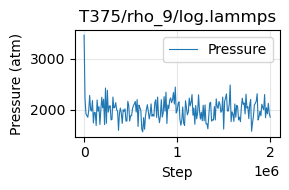

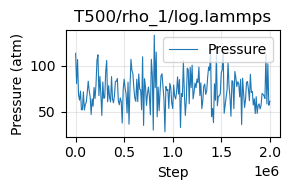

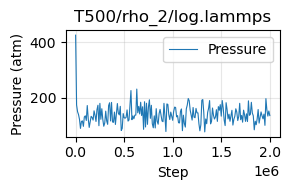

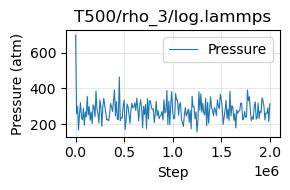

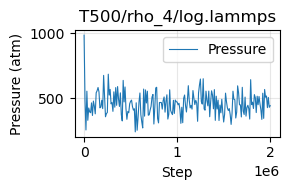

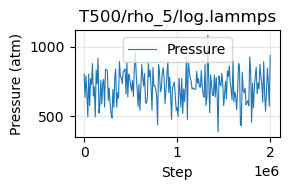

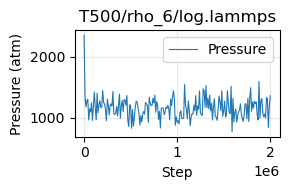

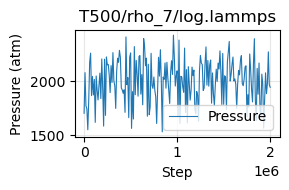

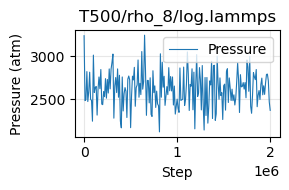

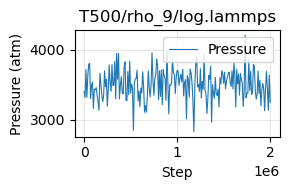

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

temperatures = [250,275,375,500]

run_to_plot = 2 

def parse_lammps_log(logfile):
    """Return list of dicts with keys 'step' and 'press' (numpy arrays)."""
    runs = []
    steps, pressures = [], []
    in_thermo = False
    col_step = col_press = None

    with open(logfile) as f:
        for line in f:
            line = line.rstrip()
            if re.match(r"\s+Step\s+", line):
                headers = line.split()
                col_step  = headers.index("Step")
                col_press = headers.index("Press")
                in_thermo = True
                continue
            if in_thermo:
                tokens = line.split()
                if tokens and all(re.match(r"^-?\d+\.?\d*([eE][+-]?\d+)?$", t) for t in tokens):
                    steps.append(int(tokens[col_step]))
                    pressures.append(float(tokens[col_press]))
                else:
                    if steps:
                        runs.append({"step": np.array(steps), "press": np.array(pressures)})
                    steps, pressures = [], []
                    in_thermo = False

    if steps:
        runs.append({"step": np.array(steps), "press": np.array(pressures)})
    return runs

for T in temperatures:
    if T == 250 or T == 275:
        no_rhos = 5
    else:
        no_rhos = 9
    for rho in range(no_rhos):
        logfile = f"T{T}/rho_{rho+1}/log.lammps"

        runs = parse_lammps_log(logfile)

        to_plot = runs if run_to_plot is None else [runs[run_to_plot - 1]]
        labels  = (list(range(1, len(runs) + 1)) if run_to_plot is None
                else [run_to_plot])

        fig, ax = plt.subplots(figsize=(3, 2))
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for i, (run_num, r) in enumerate(zip(labels, to_plot)):
            c = colors[i % len(colors)]
            ax.plot(r["step"], r["press"], lw=0.8, color=c,
                    label=f"Run {run_num}" if len(to_plot) > 1 else "Pressure")

        ax.set_xlabel("Step")
        ax.set_ylabel("Pressure (atm)")
        ax.set_title(logfile)
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()

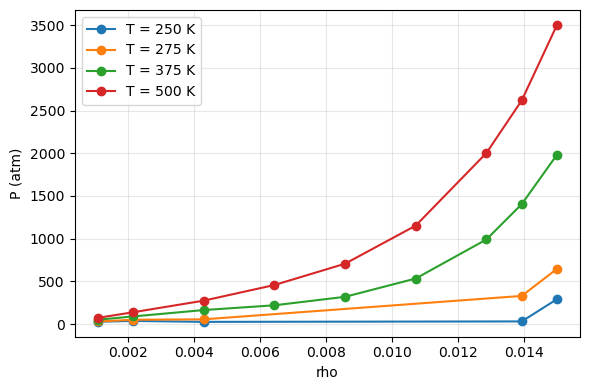

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for i, T in enumerate(temperatures):
    no_rhos = 5 if T in (250, 275) else 9
    densities = []
    with open(f"T{T}/densities.csv") as fcsv:
        for line in fcsv:
            rho_val = float(line.split(",")[0])
            densities.append(rho_val)

    avg_pressures = []
    for rho_idx in range(no_rhos):
        logfile = f"T{T}/rho_{rho_idx+1}/log.lammps"
        runs = parse_lammps_log(logfile)
        r = runs[run_to_plot - 1]
        n = len(r["press"])
        avg_pressures.append(r["press"][n // 2:].mean())
    ax.plot(densities, avg_pressures, marker="o", lw=1.5, label=f"T = {T} K")

ax.set_xlabel(r"rho")
ax.set_ylabel("P (atm)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("pressurevsdensity.png")
plt.show()